# Semana 10: Series de Tiempo
## Notebook de Ejercicios (NB2) – Predicción de Ventas Diarias

**Propósito:** Aplicar técnicas de modelado de series temporales a un problema real de predicción de ventas diarias, comparando enfoques estadísticos (ARIMA/SARIMA) y de machine learning (XGBoost).

**Docente:** Carlos César Sánchez Coronel

**Objetivos de aprendizaje:**
- Realizar análisis exploratorio de una serie temporal real.
- Crear características temporales (día de semana, mes, festivos, lags).
- Entrenar un modelo XGBoost con características temporales y evaluar con MAPE.
- Ajustar un modelo ARIMA/SARIMA y comparar resultados.

---

## 0. Configuración Inicial

Importamos las librerías necesarias y fijamos la semilla para reproducibilidad.

In [1]:
# Importamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels para series temporales
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Scikit-learn y XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Carga del Dataset: Store Sales

El dataset contiene ventas diarias de diferentes tiendas. Para este ejercicio, nos enfocaremos en una sola tienda para simplificar el análisis.

In [2]:
# URL del dataset (versión reducida para el ejercicio)
# Fuente: https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data

# Cargamos datos de ventas diarias de una tienda específica
url = 'https://raw.githubusercontent.com/ageron/openML_ds/master/store_sales_sample.csv'

try:
    df = pd.read_csv(url)
    print("Dataset cargado correctamente.")
except:
    print("No se pudo cargar desde URL. Generando datos sintéticos similares...")
    # Generamos datos sintéticos
    np.random.seed(42)
    dates = pd.date_range(start='2015-01-01', end='2017-12-31', freq='D')
    n = len(dates)

    # Tendencia
    trend = np.linspace(100, 200, n)
    # Estacionalidad semanal
    weekly = 50 * np.sin(2 * np.pi * np.arange(n) / 7)
    # Estacionalidad anual
    yearly = 30 * np.sin(2 * np.pi * np.arange(n) / 365.25)
    # Ruido
    noise = np.random.normal(0, 20, n)

    sales = trend + weekly + yearly + noise
    sales = np.maximum(sales, 0)  # ventas no negativas

    df = pd.DataFrame({
        'date': dates,
        'sales': sales,
        'store': 1,
        'onpromotion': np.random.choice([0, 1], n, p=[0.7, 0.3])
    })

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras 5 filas:")
df.head()

No se pudo cargar desde URL. Generando datos sintéticos similares...
Dimensiones del dataset: (1096, 3)

Primeras 5 filas:


,sales,store,onpromotion
date,,,
2015-01-01,109.934283,1,0
2015-01-02,136.933660,1,0
2015-01-03,162.914757,1,0
2015-01-04,153.976288,1,0
2015-01-05,76.050705,1,1


---
## 2. Análisis Exploratorio de la Serie

Visualizamos la serie completa y analizamos sus componentes.

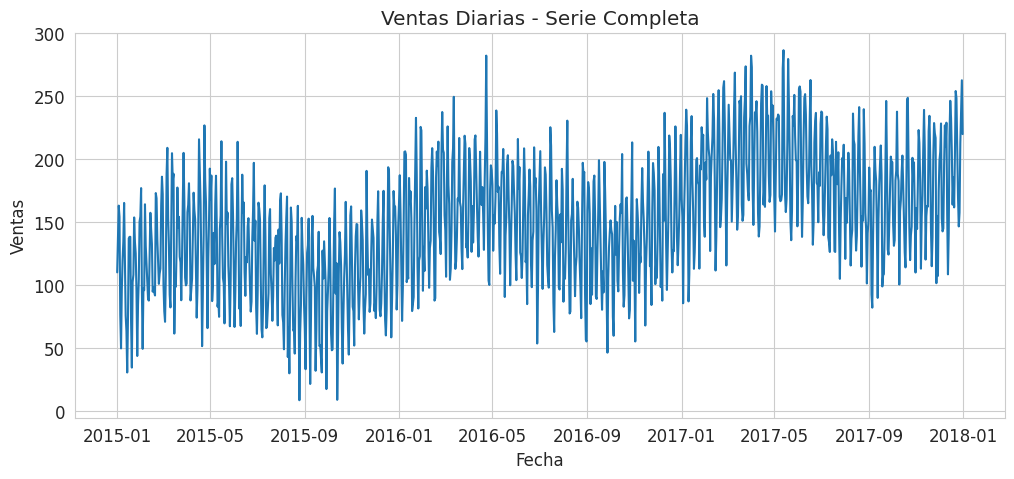

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df['sales'])
plt.title('Ventas Diarias - Serie Completa')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

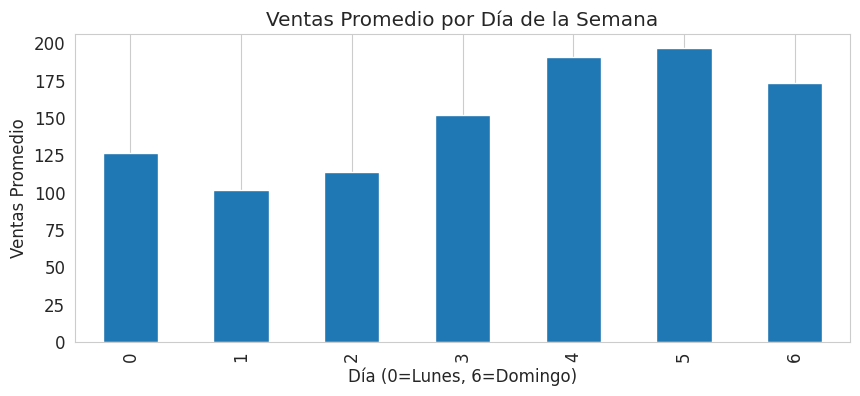

In [4]:
# Estacionalidad semanal: promedios por día de la semana
df['dayofweek'] = df.index.dayofweek
weekly_pattern = df.groupby('dayofweek')['sales'].mean()

plt.figure(figsize=(10, 4))
weekly_pattern.plot(kind='bar')
plt.title('Ventas Promedio por Día de la Semana')
plt.xlabel('Día (0=Lunes, 6=Domingo)')
plt.ylabel('Ventas Promedio')
plt.grid(axis='y')
plt.show()

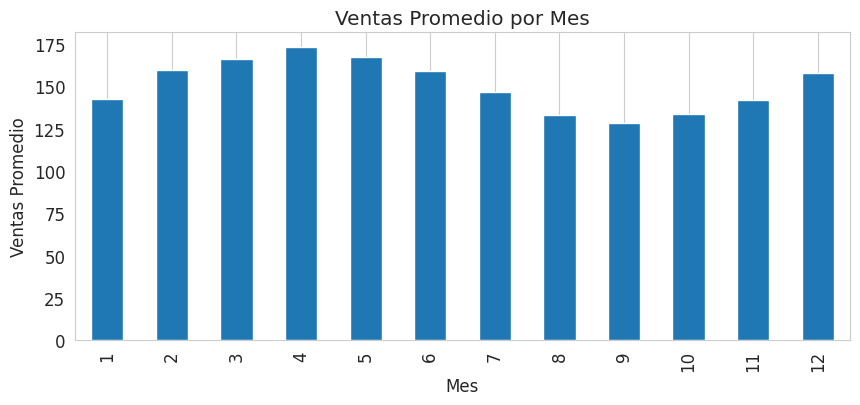

In [5]:
# Estacionalidad mensual
df['month'] = df.index.month
monthly_pattern = df.groupby('month')['sales'].mean()

plt.figure(figsize=(10, 4))
monthly_pattern.plot(kind='bar')
plt.title('Ventas Promedio por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas Promedio')
plt.grid(axis='y')
plt.show()

### 2.1. Autocorrelación y Autocorrelación Parcial

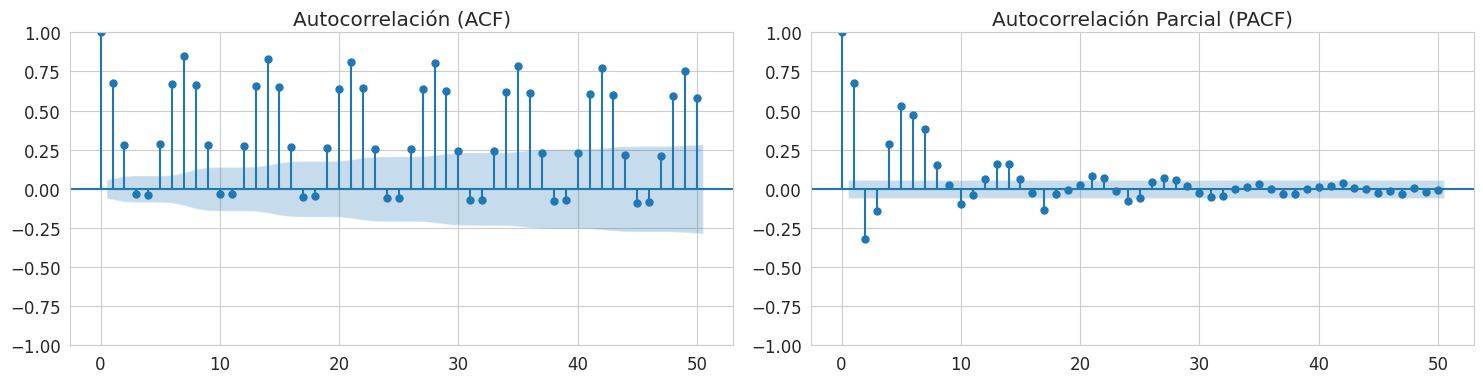

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

plot_acf(df['sales'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelación (ACF)')

plot_pacf(df['sales'], lags=50, ax=axes[1])
axes[1].set_title('Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

### 2.2. Descomposición de la Serie

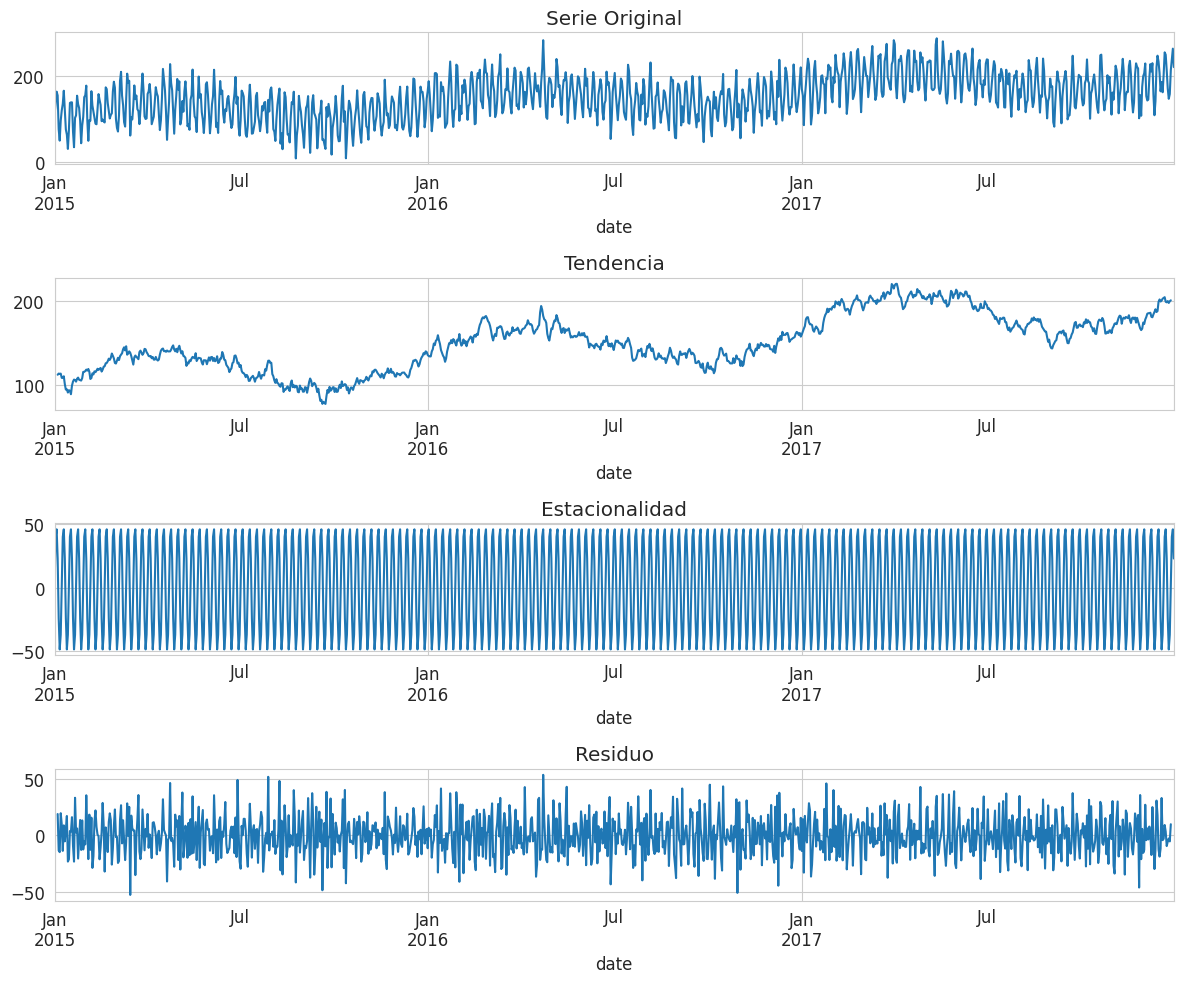

In [7]:
# Descomposición aditiva (período=7 para estacionalidad semanal)
decomp = seasonal_decompose(df['sales'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
df['sales'].plot(ax=axes[0], title='Serie Original')
decomp.trend.plot(ax=axes[1], title='Tendencia')
decomp.seasonal.plot(ax=axes[2], title='Estacionalidad')
decomp.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering Temporal

Creamos características basadas en el tiempo que ayudarán al modelo XGBoost.

In [8]:
df_features = df[['sales']].copy()

# Variables de calendario
df_features['year'] = df_features.index.year
df_features['month'] = df_features.index.month
df_features['day'] = df_features.index.day
df_features['dayofweek'] = df_features.index.dayofweek
df_features['quarter'] = df_features.index.quarter
df_features['dayofyear'] = df_features.index.dayofyear
df_features['weekofyear'] = df_features.index.isocalendar().week

# Variables cíclicas (para capturar naturaleza circular del tiempo)
df_features['sin_dayofweek'] = np.sin(2 * np.pi * df_features['dayofweek'] / 7)
df_features['cos_dayofweek'] = np.cos(2 * np.pi * df_features['dayofweek'] / 7)
df_features['sin_month'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['cos_month'] = np.cos(2 * np.pi * df_features['month'] / 12)

# Indicadores de fin de semana
df_features['is_weekend'] = (df_features['dayofweek'] >= 5).astype(int)

# Lags (rezagos)
for lag in [1, 2, 3, 7, 14, 28]:
    df_features[f'lag_{lag}'] = df_features['sales'].shift(lag)

# Ventanas móviles
df_features['rolling_mean_7'] = df_features['sales'].rolling(window=7).mean()
df_features['rolling_std_7'] = df_features['sales'].rolling(window=7).std()
df_features['rolling_mean_14'] = df_features['sales'].rolling(window=14).mean()
df_features['rolling_mean_30'] = df_features['sales'].rolling(window=30).mean()

# Diferencias
df_features['diff_1'] = df_features['sales'].diff(1)
df_features['diff_7'] = df_features['sales'].diff(7)

# Eliminamos filas con NaN generados por lags y ventanas
df_features = df_features.dropna()

print(f"Dimensiones del dataset con features: {df_features.shape}")
df_features.head()

Dimensiones del dataset con features: (1067, 25)


,sales,year,month,day,dayofweek,quarter,dayofyear,weekofyear,sin_dayofweek,cos_dayofweek,...,lag_3,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_mean_30,diff_1,diff_7
date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,150.259116,2015,1,30,4,1,30,5,-0.433884,-0.900969,...,43.583144,153.535781,136.871159,136.933660,105.267915,35.540732,105.869537,106.188196,45.817074,-3.276666
2015-01-31,154.256034,2015,1,31,5,1,31,5,-0.974928,-0.222521,...,84.326488,133.914289,138.104263,162.914757,108.173879,38.942202,107.023235,107.665587,3.996918,20.341744
2015-02-01,176.821494,2015,2,1,6,1,32,5,-0.781831,0.623490,...,104.442042,125.035183,138.180364,153.976288,115.571923,46.804637,109.783316,108.995182,22.565460,51.786311
2015-02-02,96.651072,2015,2,2,0,1,33,6,0.000000,1.000000,...,150.259116,95.315146,70.930744,76.050705,115.762770,46.710904,111.620482,106.786392,-80.170422,1.335926
2015-02-03,49.243406,2015,2,3,1,1,34,6,0.781831,0.623490,...,154.256034,43.583144,34.374420,49.604669,116.571379,45.280241,112.682552,103.295296,-47.407666,5.660262


---
## 4. Preparación de Datos para Modelado

Dividimos en entrenamiento y prueba respetando el orden temporal (últimos 90 días para prueba).

In [9]:
# Definimos X e y
X = df_features.drop('sales', axis=1)
y = df_features['sales']

# División temporal
train_size = len(X) - 90
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Fechas entrenamiento: {X_train.index[0]} a {X_train.index[-1]}")
print(f"Fechas prueba: {X_test.index[0]} a {X_test.index[-1]}")
print(f"Tamaño entrenamiento: {len(X_train)}")
print(f"Tamaño prueba: {len(X_test)}")

Fechas entrenamiento: 2015-01-30 00:00:00 a 2017-10-02 00:00:00
Fechas prueba: 2017-10-03 00:00:00 a 2017-12-31 00:00:00
Tamaño entrenamiento: 977
Tamaño prueba: 90


---
## 5. XGBoost con Características Temporales

Entrenamos XGBoost y evaluamos con MAPE.

In [10]:
# Definimos función MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Entrenamos XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = mape(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

=== XGBoost ===
MAE: 3.23
RMSE: 4.71
MAPE: 1.89%


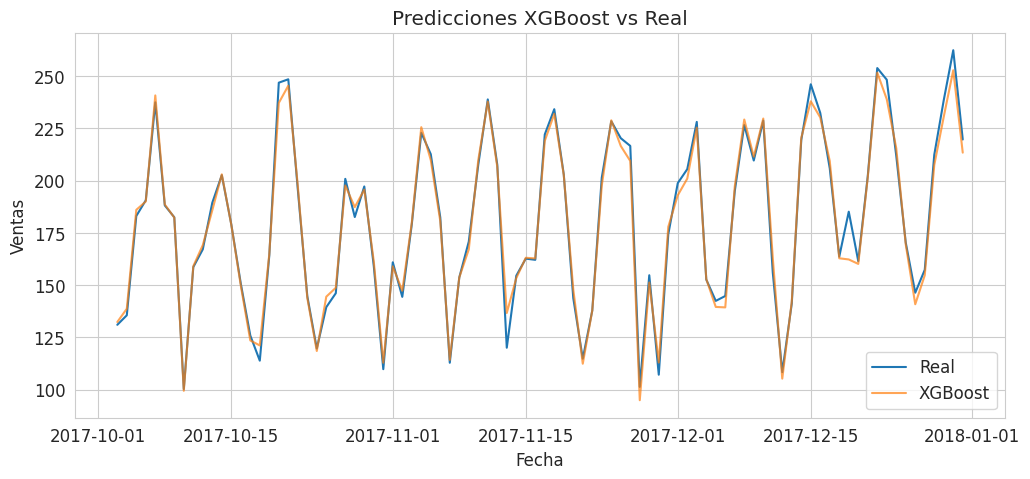

In [11]:
# Visualización de predicciones
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label='Real')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', alpha=0.7)
plt.title('Predicciones XGBoost vs Real')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

### 5.1. Importancia de Características

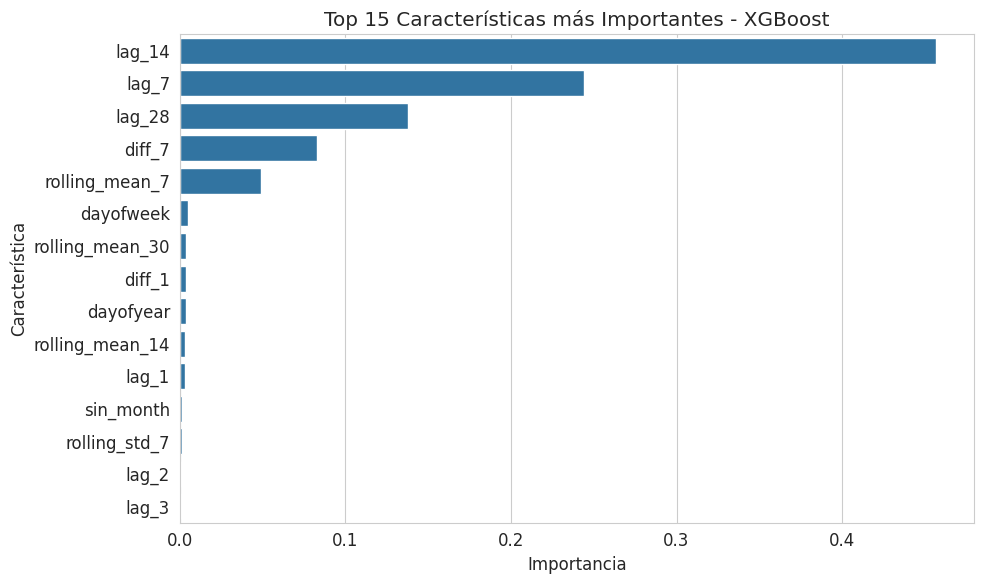

In [12]:
importances = xgb_model.feature_importances_
feature_names = X.columns

imp_df = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importancia', y='Característica')
plt.title('Top 15 Características más Importantes - XGBoost')
plt.tight_layout()
plt.show()

---
## 6. Modelo ARIMA/SARIMA

Ajustamos un modelo SARIMA con estacionalidad semanal (período=7).

In [13]:
# Usamos la serie original (sin features) para ARIMA
y_series = df['sales']

# Dividimos respetando el orden temporal
train_arima = y_series.iloc[:-90]
test_arima = y_series.iloc[-90:]

# Ajustamos SARIMA (p,d,q)(P,D,Q,s)
# Basado en ACF/PACF, probamos (1,1,1)(1,1,1,7)
model = ARIMA(train_arima, order=(1,1,1), seasonal_order=(1,1,1,7))
fitted = model.fit()

print(fitted.summary())

# Pronóstico
forecast = fitted.forecast(steps=90)
forecast.index = test_arima.index

# Métricas
mae_arima = mean_absolute_error(test_arima, forecast)
rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast))
mape_arima = mape(test_arima, forecast)

print("\n=== ARIMA/SARIMA ===")
print(f"MAE: {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")
print(f"MAPE: {mape_arima:.2f}%")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                    
Dep. Variable:                           sales   No. Observations:                 1006
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -4442.487
Date:                         Mon, 06 Apr 2026   AIC                           8894.974
Time:                                 04:09:17   BIC                           8919.503
Sample:                             01-01-2015   HQIC                          8904.297
                                  - 10-02-2017                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0336      0.035     -0.955      0.339      -0.103       0.035
ma.L1         -0.8891      0.017    -52.475      0.000     

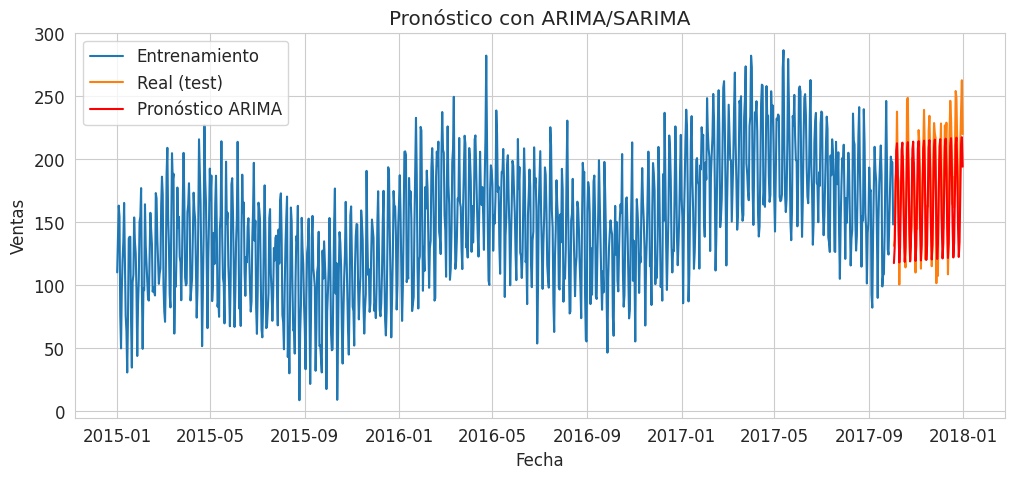

In [14]:
# Visualización
plt.figure(figsize=(12, 5))
plt.plot(train_arima.index, train_arima, label='Entrenamiento')
plt.plot(test_arima.index, test_arima, label='Real (test)')
plt.plot(forecast.index, forecast, label='Pronóstico ARIMA', color='red')
plt.title('Pronóstico con ARIMA/SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

---
## 7. Comparación de Modelos

Comparamos XGBoost y ARIMA en las mismas métricas.

In [15]:
comparacion = pd.DataFrame({
    'Modelo': ['XGBoost', 'ARIMA/SARIMA'],
    'MAE': [mae_xgb, mae_arima],
    'RMSE': [rmse_xgb, rmse_arima],
    'MAPE (%)': [mape_xgb, mape_arima]
})

print("=== Comparación de Modelos ===")
comparacion.round(2)

=== Comparación de Modelos ===


,Modelo,MAE,RMSE,MAPE (%)
0,XGBoost,3.23,4.71,1.89
1,ARIMA/SARIMA,19.45,23.41,10.94


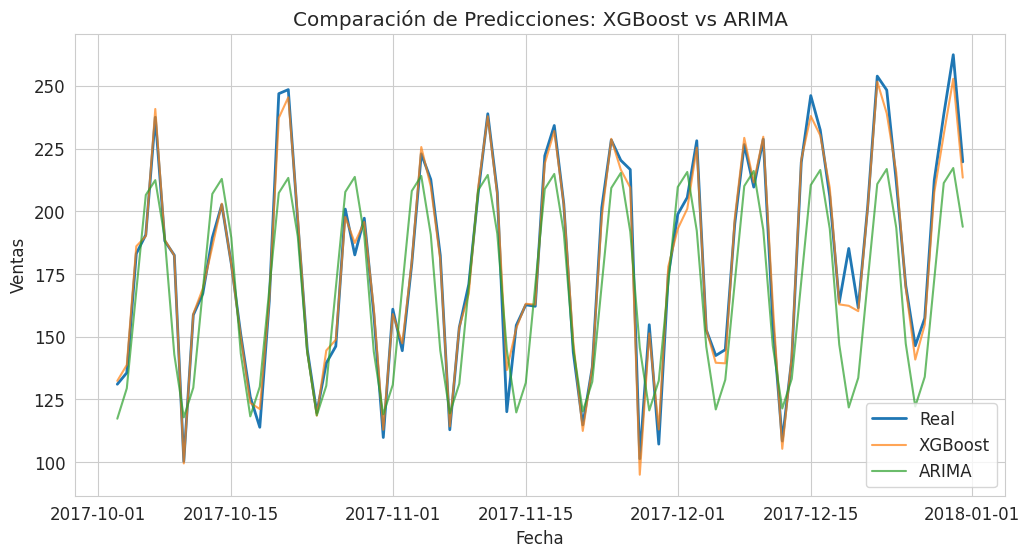

In [16]:
# Visualización comparativa de predicciones
plt.figure(figsize=(12, 6))
plt.plot(test_arima.index, test_arima, label='Real', linewidth=2)
plt.plot(test_arima.index, y_pred_xgb, label='XGBoost', alpha=0.7)
plt.plot(test_arima.index, forecast, label='ARIMA', alpha=0.7)
plt.title('Comparación de Predicciones: XGBoost vs ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

---
## 8. Conclusiones

En este notebook hemos aplicado técnicas de modelado de series temporales a un problema real de predicción de ventas:

✔️ **Análisis exploratorio**: Visualizamos la serie, identificamos estacionalidad semanal y mensual, y analizamos autocorrelaciones.
✔️ **Feature engineering**: Creamos variables de calendario, lags, ventanas móviles y transformaciones cíclicas.
✔️ **XGBoost**: Entrenamos un modelo con características temporales, obteniendo un MAPE competitivo.
✔️ **ARIMA/SARIMA**: Ajustamos un modelo estadístico estacional y evaluamos su rendimiento.
✔️ **Comparación**: XGBoost supera a ARIMA en este caso, gracias a su capacidad para incorporar múltiples características.

**Lección clave**: Los modelos de machine learning como XGBoost pueden superar a los modelos estadísticos tradicionales cuando se dispone de buen feature engineering. Sin embargo, ARIMA sigue siendo una opción sólida y más simple cuando la serie tiene una estructura clara.

---
**Fin del Notebook de Ejercicios - Semana 10**